Cost: 9.999904928931936e-05


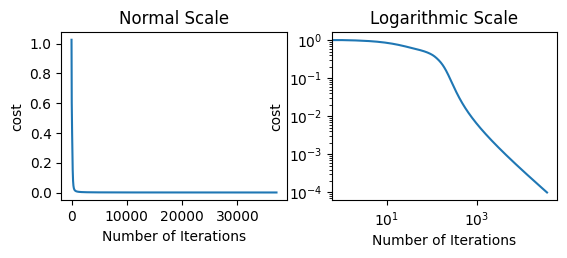

In [1]:
import random
import math
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + math.exp(-x))
def dsigmoid(x):
    s = sigmoid(x)
    return s * (1-s)

X = [
    [1, 1, 1, 0, 1, 0, 0, 1, 0], #T
    [1, 1, 1, 0, 1, 0, 1, 1, 0], #J
    [1, 1, 1, 1, 0, 1, 1, 1, 1]  #O
]
y = [
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
]
learning_rate = 0.1

ill = len(X[0])
hll = 5
oll = len(y[0])

weights_ih = [ [random.uniform(-1, 1) for i in range(ill)] for j in range(hll) ]
biases_h = [ random.uniform(-1, 1) for j in range(hll) ]
# print(f'weights: {weights_ih}\nbiases: {biases_h}')
weights_ho = [ [random.uniform(-1, 1) for j in range(hll)] for k in range(oll) ]
biases_o = [ random.uniform(-1, 1) for k in range(oll) ]


def predict(I):
    h = [
        sum( [ I[i] * weights_ih[j][i] for i in range(ill)] ) + biases_h[j] for j in range(hll)
    ]
    ah = [ sigmoid(h[j]) for j in range(hll) ]
    z = [
        sum([ ah[j] * weights_ho[k][j] for j in range(hll) ]) + biases_o[k] for k in range(oll)
    ]
    output = [ sigmoid(z[k]) for k in range(oll) ]
    return h, ah, z, output



costHistory = []

cost = 1
while cost > 0.0001:
# for r in range(1000):
    costs = []
    for p in range(X.__len__()):
        I = X[p]
        E = y[p]

        h, ah, z, output = predict(I)

        Cw_ho = [ [ 2 * (output[k]-E[k]) * dsigmoid(z[k]) * h[j] for j in range(hll) ] for k in range(oll) ]
        Cb_o = [ 2 * (output[k]-E[k]) * dsigmoid(z[k]) for k in range(oll) ]

        Cw_ih = [ 
                    [ 
                        2 * I[i] * dsigmoid(h[j]) * sum([ (output[k]-E[k]) * dsigmoid(z[k]) * weights_ho[k][j] for k in range(oll)])
                    for i in range(ill)
                ] 
            for j in range(hll)
        ]

        Cb_h = [ 2 * dsigmoid(h[j]) * sum([ (output[k]-E[k]) * dsigmoid(z[k]) * weights_ho[k][j] for k in range(oll)]) for j in range(hll)]
        
        weights_ho = [ [ weights_ho[k][j] - Cw_ho[k][j] * learning_rate for j in range(hll) ] for k in range(oll) ]
        biases_o = [ biases_o[k] - Cb_o[k] * learning_rate for k in range(oll) ]

        weights_ih = [ [ weights_ih[j][i] - Cw_ih[j][i] * learning_rate for i in range(ill)] for j in range(hll) ]
        biases_h = [ biases_h[j] - Cb_h[j] * learning_rate for j in range(hll) ]

        costs.append(sum([ math.pow(output[k]-E[k], 2) for k in range(oll) ]))

    cost = sum(costs)/len(costs)
    costHistory.append(cost)

print(f'Cost: {cost}')

plt.subplot(2, 2, 1)
plt.plot([i for i in range(len(costHistory))], costHistory)
plt.title('Normal Scale')
plt.xlabel('Number of Iterations')
plt.ylabel('cost')

plt.subplot(2, 2, 2)
plt.loglog([i for i in range(len(costHistory))], costHistory)
plt.title('Logarithmic Scale')
plt.xlabel('Number of Iterations')
plt.ylabel('cost')

plt.show()

In [2]:
c=0
t=0
accuracy=0

for i in range(100):
    test_inputs = [
        [
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0, 0.2),
        random.uniform(0.8, 1),
        random.uniform(0, 0.2),
        random.uniform(0, 0.2),
        random.uniform(0.8, 1),
        random.uniform(0, 0.2),
        ],
        [
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0, 0.2),
        random.uniform(0.8, 1),
        random.uniform(0, 0.2),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0, 0.2),
        ],
        [
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0, 0.2),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        random.uniform(0.8, 1),
        ]
    ]
    answer = ['T', 'J', 'O']
    
    v = random.randrange(3)
    test_input = test_inputs[v]
    
    a, b, z, o = predict(test_input)
    # print(o)
    prediction = o.index(max(o))
    c += 1 if prediction == v else 0
    t += 1
    # print(f'Predicted: {answer[prediction]}\nActual: {answer[t]}')

accuracy = c/t
accuracy

0.99